In [2]:
import pandas as pd
import numpy as npa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df=pd.read_csv('canada_per_capita_income.csv')

df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [20]:
df.isnull().sum()

year                       0
per capita income (US$)    0
dtype: int64

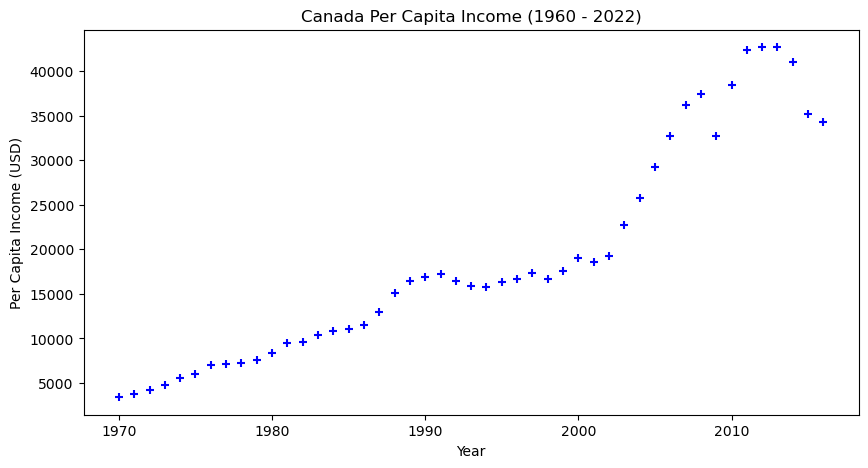

In [6]:
# Visualize the historical trend
plt.figure(figsize=(10, 5))
plt.scatter(df['year'], df['per capita income (US$)'], color='blue', marker='+')
plt.title('Canada Per Capita Income (1970 - 2016)')
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US $)')
plt.show()

In [8]:
# Define our independent variable (X) and dependent variable (y)
X = df[['year']] # Features must be a 2D array/Dataframe
y = df['per capita income (US$)'] # Target variable

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")

Training data size: 37
Testing data size: 10


In [10]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Model Coefficient (Slope): 815.14
Model Intercept: -1605560.20


In [12]:
# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")


Mean Squared Error: 15147815.55
R-squared Score: 0.8752


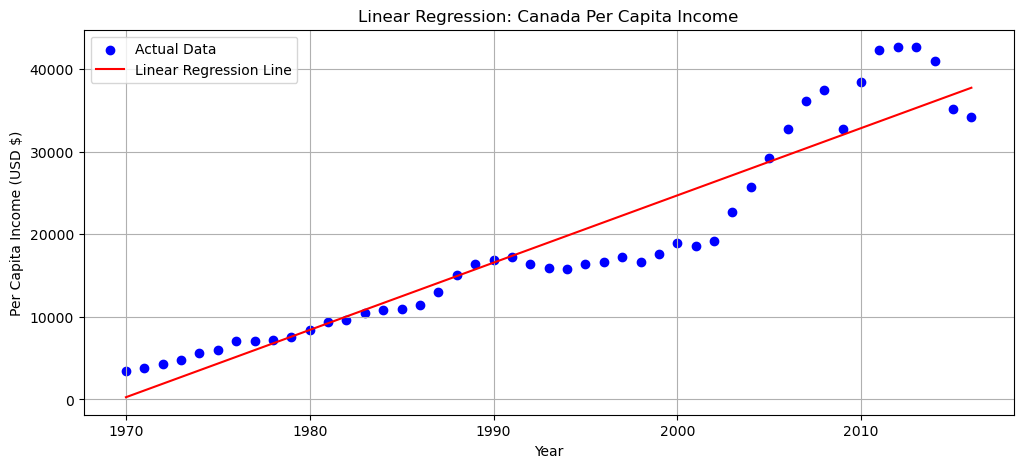

In [24]:
# Plot the actual data points
plt.figure(figsize=(12, 5))
plt.scatter(df['year'], df['per capita income (US$)'], color='blue', label='Actual Data')

# Plot the predicted regression line over the entire dataset
plt.plot(df['year'], model.predict(df[['year']]), color='red', label='Linear Regression Line')

plt.title('Linear Regression: Canada Per Capita Income')
plt.xlabel('Year')
plt.ylabel('Per Capita Income (USD $)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Let's predict the per capita income for a future year, like 2026 or 2030
future_years = pd.DataFrame({'year': [2020, 2022, 2024,2026]})
predictions = model.predict(future_years)

for year, pred in zip(future_years['year'], predictions):
    print(f"Predicted Per Capita Income in {year}: ${pred:.2f}")

Predicted Per Capita Income in 2020: $41027.68
Predicted Per Capita Income in 2022: $42657.96
Predicted Per Capita Income in 2024: $44288.25
Predicted Per Capita Income in 2026: $45918.53
